In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
trades = pd.read_csv("../data/trade_log.csv")

In [22]:
trades.head()

,TradeID,PairName,StrategyName,SignalType,Direction,EntryPrice,ExitPrice,EntryDateTime,ExitDateTime,PositionSize,PnL,PnL_Pips,HoldingDays,Commission,IsOpen
0,1,USD/JPY,MACD_Trend,BUY,LONG,154.16999,154.17229,2024-07-15,2024-07-17 23:45:36.000000000,100000,2300.0,23.0,2.99,7.0,False
1,2,USD/INR,MA_Cross,STRONG_SELL,SHORT,83.90144,83.90070,2024-02-08,2024-02-10 11:45:36.000000000,100000,740.0,7.4,2.49,7.0,False
2,3,USD/JPY,RL_PPO,BUY,LONG,150.56125,150.56093,2024-06-26,2024-06-28 10:19:12.000000000,100000,-320.0,-3.2,2.43,7.0,False
3,4,GBP/USD,ML_RF,SELL,SHORT,1.23636,1.23434,2024-03-26,2024-03-28 14:24:00.000000000,100000,202.0,20.2,2.60,7.0,False
4,5,AUD/USD,RL_PPO,BUY,LONG,0.66810,0.66700,2024-06-05,2024-06-06 11:02:24.000000000,100000,-110.0,-11.0,1.46,7.0,False


In [23]:
trades.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   TradeID        150 non-null    int64  
 1   PairName       150 non-null    str    
 2   StrategyName   150 non-null    str    
 3   SignalType     150 non-null    str    
 4   Direction      150 non-null    str    
 5   EntryPrice     150 non-null    float64
 6   ExitPrice      150 non-null    float64
 7   EntryDateTime  150 non-null    str    
 8   ExitDateTime   150 non-null    str    
 9   PositionSize   150 non-null    int64  
 10  PnL            150 non-null    float64
 11  PnL_Pips       150 non-null    float64
 12  HoldingDays    150 non-null    float64
 13  Commission     150 non-null    float64
 14  IsOpen         150 non-null    bool   
dtypes: bool(1), float64(6), int64(2), str(6)
memory usage: 16.7 KB


In [24]:
trades.describe()

,TradeID,EntryPrice,ExitPrice,PositionSize,PnL,PnL_Pips,HoldingDays,Commission
count,150.000000,150.000000,150.000000,150.0,150.000000,150.000000,150.000000,150.0
mean,75.500000,41.894922,41.895088,100000.0,12.766667,2.806667,2.407333,7.0
std,43.445368,58.152366,58.152166,0.0,1664.847964,28.992708,1.373833,0.0
min,1.000000,0.643510,0.638620,100000.0,-6590.000000,-77.500000,0.120000,7.0
25%,38.250000,1.059195,1.057743,100000.0,-288.750000,-17.450000,1.297500,7.0
50%,75.500000,1.237020,1.237965,100000.0,70.000000,5.000000,2.470000,7.0
75%,112.750000,83.094157,83.094285,100000.0,345.250000,21.550000,3.417500,7.0
max,150.000000,154.169990,154.172290,100000.0,6050.000000,78.600000,4.970000,7.0


In [25]:
total_trades = trades["TradeID"].nunique()

print("Total Trades:", total_trades)

Total Trades: 150


In [26]:
winning_trades = (trades["PnL"] > 0).sum()

losing_trades = (trades["PnL"] < 0).sum()

print("Winning Trades:", winning_trades)

print("Losing Trades:", losing_trades)

Winning Trades: 84
Losing Trades: 66


In [27]:
win_rate = (
    (trades["PnL"] > 0).mean()
) * 100

print("Win Rate:", round(win_rate,2), "%")

Win Rate: 56.0 %


In [28]:
total_pnl = trades["PnL"].sum()

print("Total PnL:", total_pnl)

Total PnL: 1915.0


In [29]:
avg_pnl = trades["PnL"].mean()

print("Average Trade PnL:", avg_pnl)

Average Trade PnL: 12.766666666666667


In [30]:
pair_pnl = trades.groupby(
    "PairName"
)["PnL"].sum().sort_values(
    ascending=False
)

pair_pnl

PairName
USD/INR    4720.0
GBP/USD    4511.0
AUD/USD      29.0
EUR/USD     -75.0
USD/JPY   -7270.0
Name: PnL, dtype: float64

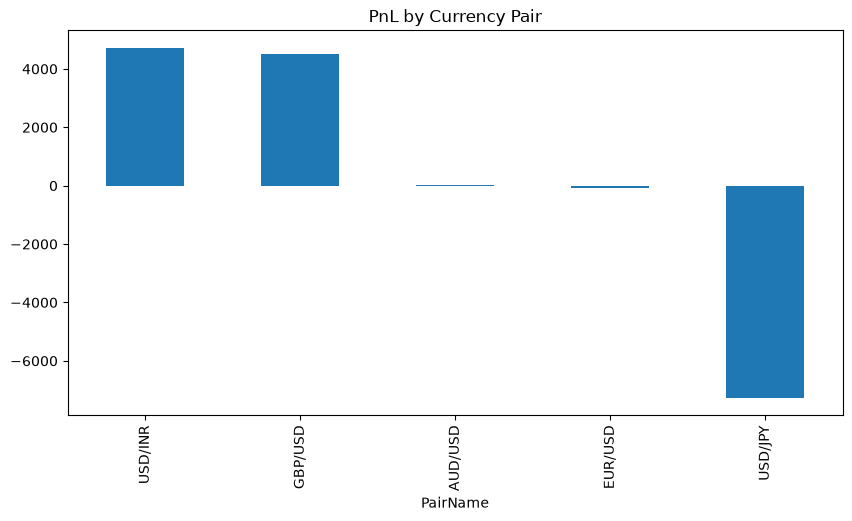

In [31]:
pair_pnl.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("PnL by Currency Pair")

plt.show()

In [32]:
strategy_pnl = trades.groupby(
    "StrategyName"
)["PnL"].sum().sort_values(
    ascending=False
)

strategy_pnl

StrategyName
ML_RF           11051.0
ML_XGB           9690.0
MA_Cross         4217.0
RL_PPO          -1767.0
RSI_Reversal    -1880.0
MACD_Trend      -5934.0
Composite      -13462.0
Name: PnL, dtype: float64

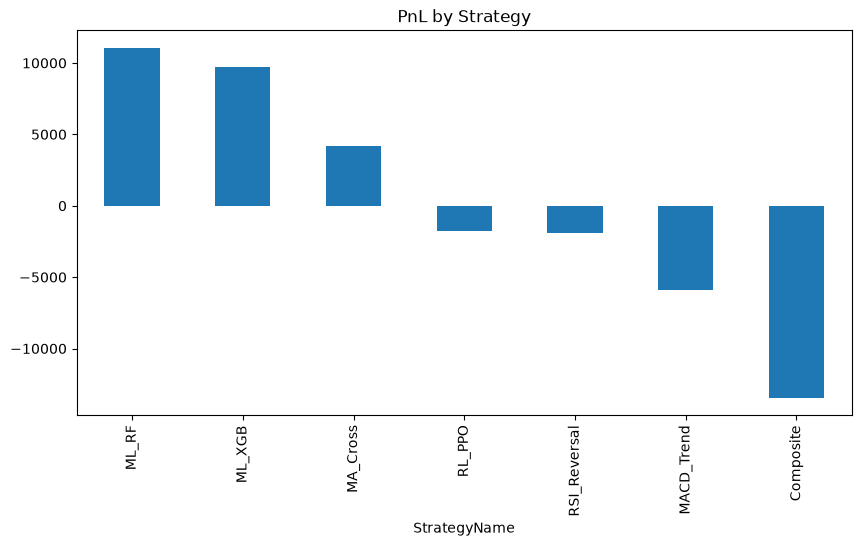

In [33]:
strategy_pnl.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("PnL by Strategy")

plt.show()

In [34]:
direction_pnl = trades.groupby(
    "Direction"
)["PnL"].sum()

direction_pnl

Direction
LONG     3467.0
SHORT   -1552.0
Name: PnL, dtype: float64

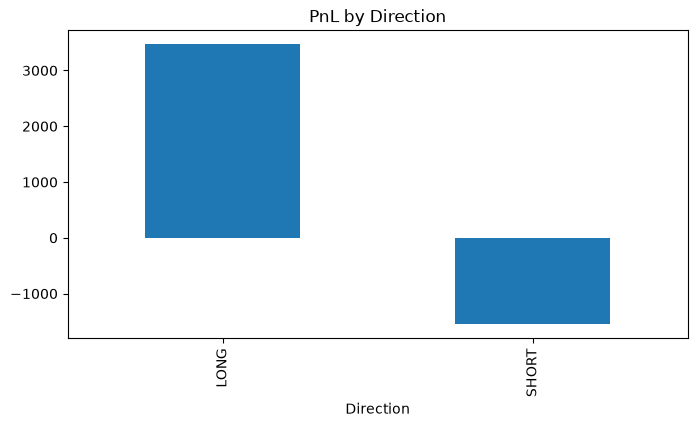

In [35]:
direction_pnl.plot(
    kind="bar",
    figsize=(8,4)
)

plt.title("PnL by Direction")

plt.show()

In [36]:
print(
    "Total Commission:",
    trades["Commission"].sum()
)

Total Commission: 1050.0


In [37]:
print(
    "Average Holding Days:",
    trades["HoldingDays"].mean()
)

Average Holding Days: 2.407333333333333


In [38]:
trades.sort_values(
    "PnL",
    ascending=False
).head(10)

,TradeID,PairName,StrategyName,SignalType,Direction,EntryPrice,ExitPrice,EntryDateTime,ExitDateTime,PositionSize,PnL,PnL_Pips,HoldingDays,Commission,IsOpen
79,80,USD/INR,RSI_Reversal,STRONG_SELL,SHORT,82.85240,82.84635,2024-08-17,2024-08-19 02:09:36.000000000,100000,6050.0,60.5,2.09,7.0,False
43,44,USD/INR,ML_RF,BUY,LONG,82.99557,83.00088,2024-04-20,2024-04-24 11:31:12.000000000,100000,5310.0,53.1,4.48,7.0,False
78,79,USD/JPY,ML_RF,STRONG_BUY,LONG,153.35576,153.36083,2024-05-05,2024-05-05 10:33:36.000000000,100000,5070.0,50.7,0.44,7.0,False
62,63,USD/JPY,ML_RF,SELL,SHORT,140.52009,140.51519,2024-02-18,2024-02-21 05:45:36.000000000,100000,4900.0,49.0,3.24,7.0,False
19,20,USD/JPY,RL_PPO,STRONG_BUY,LONG,145.35153,145.35617,2024-07-08,2024-07-09 13:12:00.000000000,100000,4640.0,46.4,1.55,7.0,False
32,33,USD/INR,ML_XGB,STRONG_BUY,LONG,82.55310,82.55690,2024-07-24,2024-07-25 23:31:12.000000000,100000,3800.0,38.0,1.98,7.0,False
22,23,USD/JPY,ML_XGB,STRONG_SELL,SHORT,151.00825,151.00459,2024-04-07,2024-04-08 20:09:36.000000000,100000,3660.0,36.6,1.84,7.0,False
52,53,USD/JPY,MA_Cross,SELL,SHORT,145.89656,145.89321,2024-02-10,2024-02-11 06:00:00.000000000,100000,3350.0,33.5,1.25,7.0,False
99,100,USD/INR,ML_XGB,BUY,LONG,82.78943,82.79188,2024-01-15,2024-01-18 20:38:24.000000000,100000,2450.0,24.5,3.86,7.0,False
0,1,USD/JPY,MACD_Trend,BUY,LONG,154.16999,154.17229,2024-07-15,2024-07-17 23:45:36.000000000,100000,2300.0,23.0,2.99,7.0,False


In [39]:
trades.sort_values(
    "PnL"
).head(10)

,TradeID,PairName,StrategyName,SignalType,Direction,EntryPrice,ExitPrice,EntryDateTime,ExitDateTime,PositionSize,PnL,PnL_Pips,HoldingDays,Commission,IsOpen
104,105,USD/JPY,MACD_Trend,STRONG_BUY,LONG,149.24642,149.23983,2024-04-23,2024-04-25 03:07:12.000000000,100000,-6590.0,-65.9,2.13,7.0,False
54,55,USD/JPY,Composite,BUY,LONG,146.29441,146.28888,2024-01-08,2024-01-10 23:02:23.999999999,100000,-5530.0,-55.3,2.96,7.0,False
96,97,USD/JPY,RSI_Reversal,STRONG_BUY,LONG,153.98817,153.98310,2024-04-09,2024-04-12 00:43:12.000000000,100000,-5070.0,-50.7,3.03,7.0,False
115,116,USD/INR,Composite,SELL,SHORT,82.31774,82.32196,2024-02-17,2024-02-19 08:24:00.000000000,100000,-4220.0,-42.2,2.35,7.0,False
117,118,USD/JPY,ML_RF,STRONG_SELL,SHORT,148.32031,148.32420,2024-07-25,2024-07-28 04:33:36.000000000,100000,-3890.0,-38.9,3.19,7.0,False
149,150,USD/JPY,ML_XGB,STRONG_SELL,SHORT,152.47311,152.47611,2024-02-14,2024-02-17 15:21:36.000000000,100000,-3000.0,-30.0,3.64,7.0,False
59,60,USD/JPY,RL_PPO,BUY,LONG,153.05951,153.05702,2024-07-08,2024-07-11 15:50:24.000000000,100000,-2490.0,-24.9,3.66,7.0,False
86,87,USD/INR,MACD_Trend,STRONG_SELL,SHORT,83.41436,83.41675,2024-05-17,2024-05-18 23:02:24.000000000,100000,-2390.0,-23.9,1.96,7.0,False
63,64,USD/INR,Composite,SELL,SHORT,82.84328,82.84566,2024-03-18,2024-03-18 16:47:59.999999999,100000,-2380.0,-23.8,0.70,7.0,False
106,107,USD/INR,RSI_Reversal,SELL,SHORT,84.17042,84.17274,2024-06-17,2024-06-17 06:57:35.999999999,100000,-2320.0,-23.2,0.29,7.0,False


In [40]:
summary = pd.DataFrame({

    "Metric":[
        "Total Trades",
        "Win Rate",
        "Total PnL",
        "Average Trade PnL"
    ],

    "Value":[
        total_trades,
        win_rate,
        total_pnl,
        avg_pnl
    ]
})

summary

,Metric,Value
0,Total Trades,150.000000
1,Win Rate,56.000000
2,Total PnL,1915.000000
3,Average Trade PnL,12.766667
